# Домашнє завдання: Алгоритми навчання з вчителем Ч.1
**Датасет:** California Housing

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

# Налаштування стилю для графіків
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 120})

print("Пакети імпортовано успішно!")

Пакети імпортовано успішно!


In [14]:
# Завантажуємо набір даних California Housing
california_housing = fetch_california_housing(as_frame=True)
data = california_housing.frame

print(f"Розмірність початкового датасету: {data.shape}")
display(data.head())

Розмірність початкового датасету: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Обробка даних (Кореляція та Викиди)

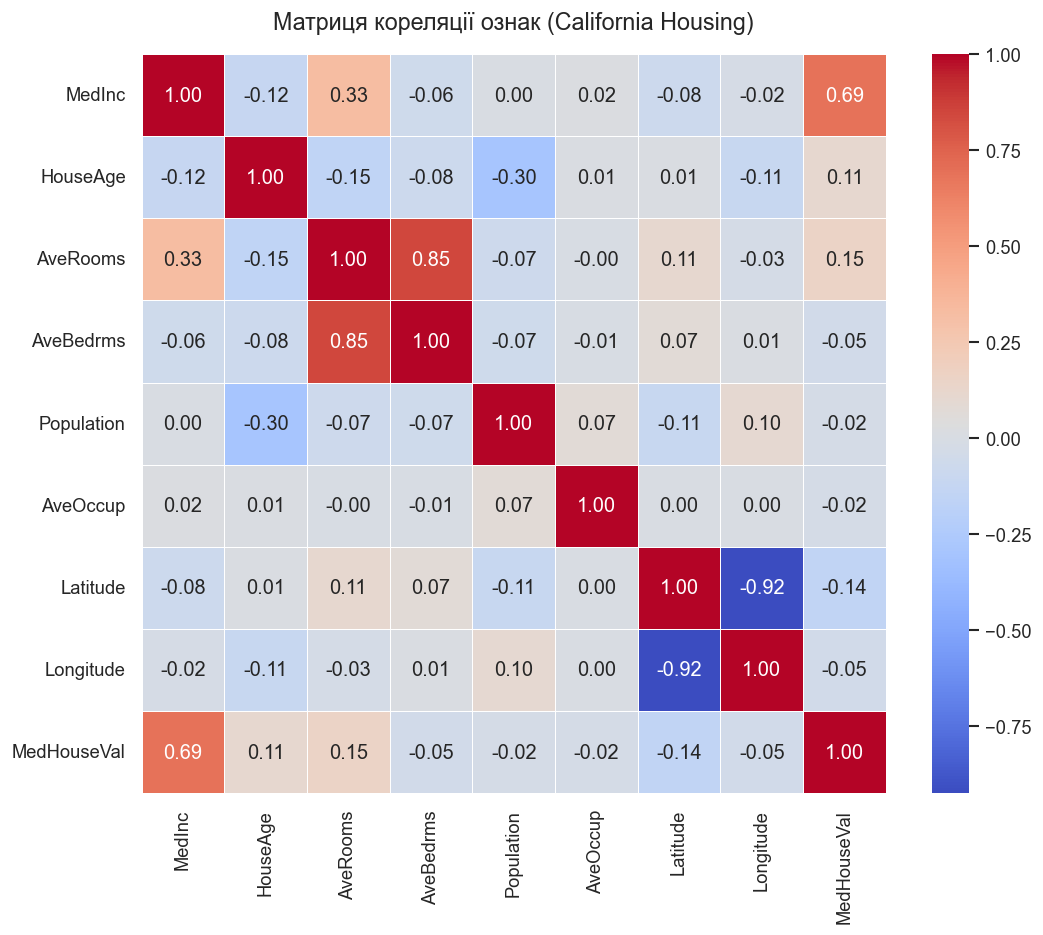

In [15]:
# Побудова матриці кореляції для виявлення мультиколінеарності
plt.figure(figsize=(10, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Матриця кореляції ознак (California Housing)", fontsize=14, pad=15)
plt.show()

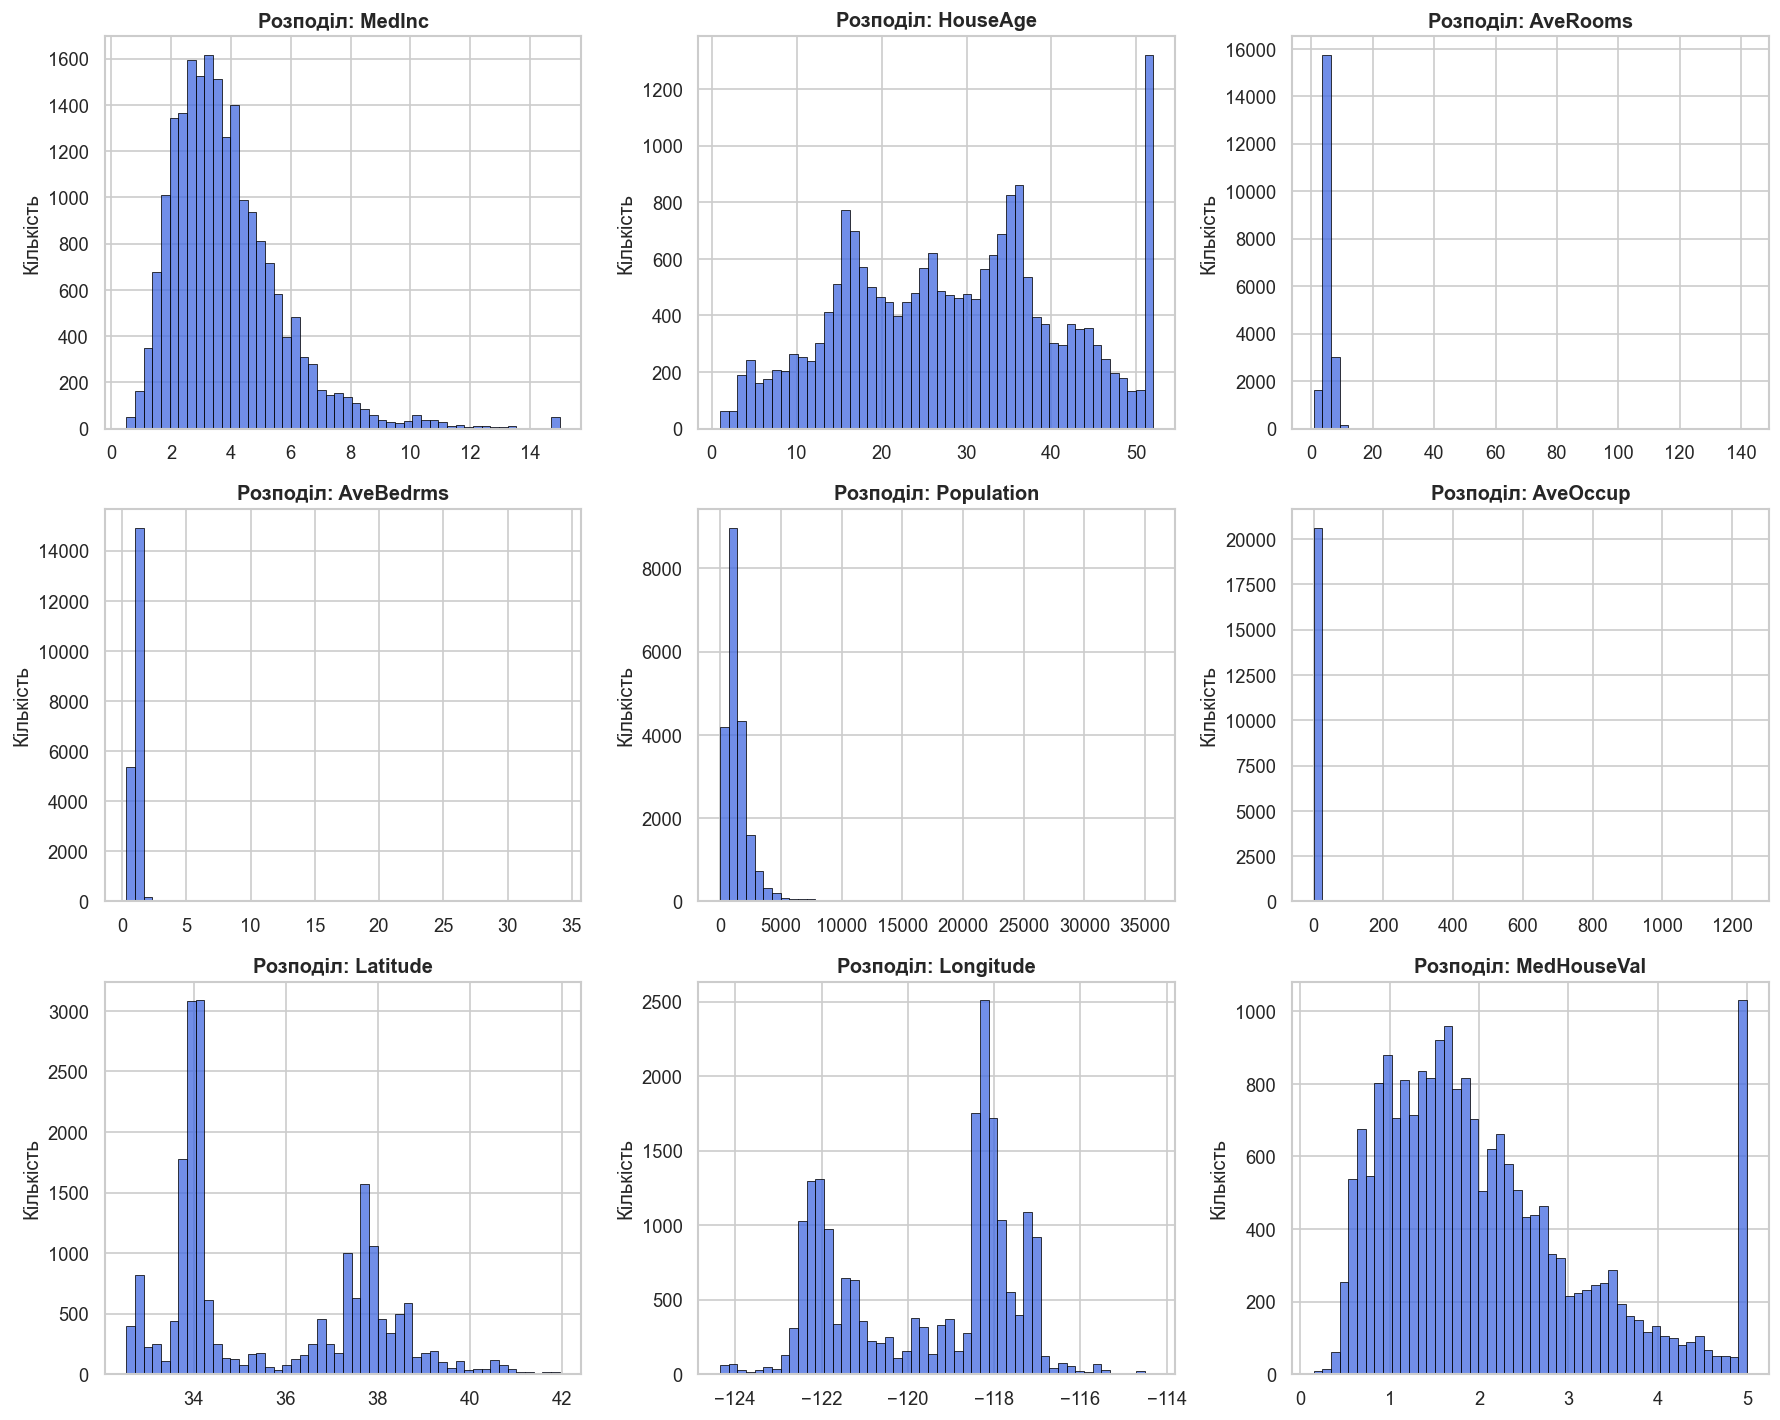

In [16]:
# Створюємо сітку 3х3 для всіх 9 ознак датасету
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten() # Робимо масив осей плоским

# Проходимося по всіх колонках датасету
for i, col in enumerate(data.columns):
    # Будуємо гістограму
    sns.histplot(data[col], bins=50, ax=axes[i], color='royalblue', edgecolor='black')
    axes[i].set_title(f'Розподіл: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Кількість')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### Висновки з EDA

Аналіз матриці кореляцій та гістограм розподілу всіх ознак датасету виявив дві ключові проблеми:

1. **Мультиколінеарність:** Ознаки `AveRooms` та `AveBedrms` мають високу лінійну кореляцію ($r \approx 0.85$). Наявність обох ознак дестабілізує ваги лінійної регресії. Ми видалимо `AveBedrms`.
2. **Екстремальні викиди:** Розподіли ознак `AveRooms`, `AveBedrms`, `Population` та `AveOccup` візуально виглядають як один або декілька масивних стовпців, притиснутих до нуля, з 
довгою порожньою віссю X. Це свідчить про наявність одиничних аномальних значень (наприклад, понад 100 кімнат в одному "будинку"), які викривляють загальний тренд. Інші ознаки (наприклад, `MedInc` чи `HouseAge`) мають адекватний розподіл. Тому ми застосуємо статистичний фільтр Z-score ($|Z| > 3$) для цих чотирьох проблемних колонок.

In [17]:
# 1. Очищення від викидів (Z-score) для 4 специфічних колонок
cols_to_check = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']

z_scores = data[cols_to_check].apply(zscore)

# Шукаємо аномалії (z-score > 3 або < -3).
outliers_mask = (z_scores.abs() > 3).any(axis=1)

# Залишаємо лише нормальні дані
data_clean = data[~outliers_mask].copy()

# 2. Видалення скорельованої ознаки
feature_to_drop = 'AveBedrms'
data_clean.drop(columns=[feature_to_drop], inplace=True)

print(f"Розмірність після очищення: {data_clean.shape}")
print(f"Видалено рядків з аномаліями: {data.shape[0] - data_clean.shape[0]}")
print(f"Видалено ознаку: '{feature_to_drop}'")

Розмірність після очищення: (20135, 8)
Видалено рядків з аномаліями: 505
Видалено ознаку: 'AveBedrms'


### Зауваження щодо методології: Очищення даних vs. Data Leakage

Згідно з покроковою інструкцією до цього домашнього завдання, очищення від викидів за допомогою Z-score було проведено до розбиття датасету на навчальну та тестову вибірки (Кроки 3 і 4). 

In [8]:
# Розбиття вхідного набору даних на навчальну і тестову вибірки
X = data_clean.drop(columns=['MedHouseVal'])
y = data_clean['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Нормалізація ознак
scaler = StandardScaler()
# Навчаємо тільки на тренувальній вибірці (fit_transform)
X_train_scaled = scaler.fit_transform(X_train)
# Тестову вибірку лише трансформуємо (transform), щоб уникнути Data Leakage
X_test_scaled = scaler.transform(X_test)

# Побудова моделі LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Оцінка показників моделі
y_pred = model.predict(X_test_scaled)

r_sq_upd = r2_score(y_test, y_pred) 
mae_upd = mean_absolute_error(y_test, y_pred)
mape_upd = mean_absolute_percentage_error(y_test, y_pred)

print("\n=== ФІНАЛЬНІ ПОКАЗНИКИ ОНОВЛЕНОЇ МОДЕЛІ ===")
print(f"R2 (Коефіцієнт детермінації): {r_sq_upd:.2f}")
print(f"MAE (Середня абсолютна похибка): {mae_upd:.2f}")
print(f"MAPE (Середня абсолютна похибка у %): {mape_upd:.2f}")


=== ФІНАЛЬНІ ПОКАЗНИКИ ОНОВЛЕНОЇ МОДЕЛІ ===
R2 (Коефіцієнт детермінації): 0.65
MAE (Середня абсолютна похибка): 0.51
MAPE (Середня абсолютна похибка у %): 0.30


### Порівняння метрик та загальні висновки

**Порівняння результатів:**
* **Базова модель (з лекції):** $R^2 \approx 0.60$ | MAE $\approx 0.53$ | MAPE $\approx 0.31$
* **Оновлена модель (з ДЗ):** $R^2 = 0.65$ | MAE $= 0.51$ | MAPE $= 0.30$

**Висновки:**

1. Завдяки додатковій передобробці даних коефіцієнт детермінації ($R^2$) зріс на 5 відсоткових пунктів. Абсолютні та відносні похибки (MAE, MAPE) також знизилися.
2. Видалення екстремальних аномалій (Z-score > 3) у колонках кількості кімнат та населення відіграло позитивну роль. Видалення, наприклад, одиничних "будинків" зі 140 кімнатами дозволило лінії регресії адекватно підлаштуватися під основний масив нормальних даних.
3. Видалення ознаки `AveBedrms`, яка на 85% дублювала інформацію з `AveRooms`, зменшило нестабільність ваг (коефіцієнтів) нашої моделі. 

### Експеримент 1: PolynomialFeatures + Clipping цільової змінної

Для подальшого покращення метрик застосуємо два підходи:
1. **Генерація поліноміальних ознак:** Дозволить моделі враховувати попарні взаємодії між ознаками (наприклад, `MedInc` $\times$ `HouseAge`) та їх квадратичні залежності.
2. **Clipping** (як у коді з лекції): Оскільки цільова змінна `MedHouseVal` у нашому датасеті жорстко обмежена діапазоном від $\approx 0.15$ до $5.0$, ми примусово обмежимо прогнози моделі цими межами. Це захистить нас від математично можливих, але фізично нереальних прогнозів (наприклад, від'ємної вартості житла).

In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Створюємо пайплайн: Поліноміальні ознаки -> Нормалізація -> Регресія
poly_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LinearRegression()
)

# 2. Навчаємо пайплайн на оригінальних тренувальних даних.
poly_pipeline.fit(X_train, y_train)

# 3. Прогнозування на тестовій вибірці
y_pred_poly_raw = poly_pipeline.predict(X_test)

# 4. Застосовуємо Clipping
# Беремо мінімальне та максимальне значення з тренувальної вибірки, 
MIN_PRICE = 0.14999
MAX_PRICE = 5.00001
y_pred_poly_clipped = np.clip(y_pred_poly_raw, MIN_PRICE, MAX_PRICE)

# 5. Оцінка метрик нового експерименту
r_sq_poly = r2_score(y_test, y_pred_poly_clipped)
mae_poly = mean_absolute_error(y_test, y_pred_poly_clipped)
mape_poly = mean_absolute_percentage_error(y_test, y_pred_poly_clipped)

print("=== РЕЗУЛЬТАТИ ЕКСПЕРИМЕНТУ (Polynomial + Clipping) ===")
print(f"Кількість ознак після поліномізації: {poly_pipeline.named_steps['polynomialfeatures'].n_output_features_}")
print(f"R2 (на Test): {r_sq_poly:.2f}")
print(f"MAE (Середня абсолютна похибка): {mae_poly:.2f}")
print(f"MAPE (Середня абсолютна похибка у %): {mape_poly:.2f}")

=== РЕЗУЛЬТАТИ ЕКСПЕРИМЕНТУ (Polynomial + Clipping) ===
Кількість ознак після поліномізації: 35
R2 (на Test): 0.72
MAE (Середня абсолютна похибка): 0.45
MAPE (Середня абсолютна похибка у %): 0.25


### Висновки та результати експериментів

**Метрики моделі:**
1. **Базова модель (з лекції):** $R^2 \approx 0.60$ | MAE $\approx 0.53$ | MAPE $\approx 0.31$
2. **Після очищення (Z-score + видалення мультиколінеарності):** $R^2 \approx 0.65$ | MAE $\approx 0.51$ | MAPE $\approx 0.30$
3. **Експеримент (PolynomialFeatures + Clipping):** $R^2 = 0.72$ | MAE $= 0.45$ | MAPE $= 0.25$

**Підсумок:**

1. Трансформація простору ознак за допомогою `PolynomialFeatures` (розширення з 7 до 35 змінних) дозволила простій лінійній моделі вловити приховані нелінійні взаємодії (наприклад, поєднання віку будинку та рівня доходу).

2. Використання функції `np.clip` для жорсткого обмеження прогнозів фізичними межами датасету (від 0.15 до 5.0) захистило модель від генерації нереалістичних цін, і зменшило середню абсолютну похибку (MAE).

### Експеримент 2: Просторовий аналіз (Гео-ознаки)

Вартість нерухомості в Каліфорнії має географічну специфіку. Будинки, розташовані на океанському узбережжі коштують значно дорожче за нерухомість у глибині континенту. 

Щоб допомогти моделі вловити просторову нелінійність, ми створимо нову синтетичну ознаку: Евклідову відстань від кожного будинку до найближчого економічного хабу (SF або LA). 

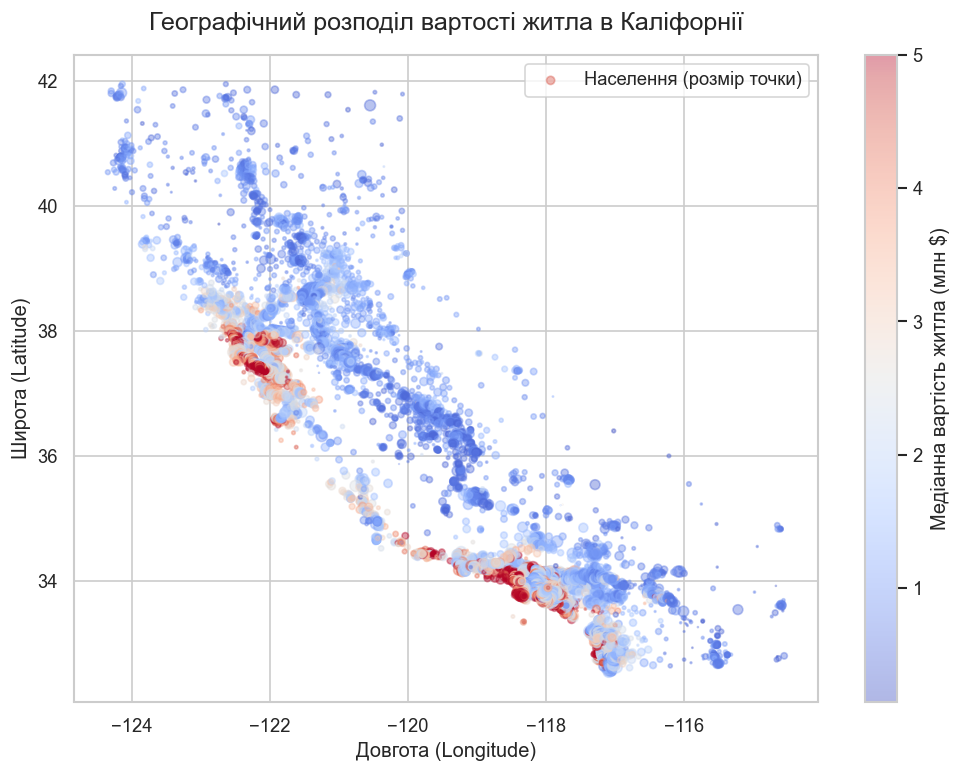

In [19]:
# Будуємо географічну карту розподілу цін на житло
plt.figure(figsize=(10, 7))

# Використовуємо довготу (X) та широту (Y). 
sc = plt.scatter(data_clean['Longitude'], data_clean['Latitude'], 
                 alpha=0.4, 
                 s=data_clean['Population'] / 100, 
                 c=data_clean['MedHouseVal'], 
                 cmap='coolwarm', 
                 label='Населення (розмір точки)')

plt.colorbar(sc, label='Медіанна вартість житла (млн $)')
plt.xlabel('Довгота (Longitude)', fontsize=12)
plt.ylabel('Широта (Latitude)', fontsize=12)
plt.title('Географічний розподіл вартості житла в Каліфорнії', fontsize=15, pad=15)
plt.legend()
plt.show()

In [20]:
# 1. Генерація нової просторової ознаки
# Координати центрів (Широта, Довгота)
SF_COORDS = (37.7749, -122.4194) # Сан-Франциско
LA_COORDS = (34.0522, -118.2437) # Лос-Анджелес

def distance_to_nearest_hub(lat, lon):
    # Розрахунок Евклідової відстані
    dist_sf = np.sqrt((lat - SF_COORDS[0])**2 + (lon - SF_COORDS[1])**2)
    dist_la = np.sqrt((lat - LA_COORDS[0])**2 + (lon - LA_COORDS[1])**2)
    return min(dist_sf, dist_la)

# Додаємо нову колонку до масиву ознак
X_geo = X.copy()
X_geo['Dist_to_CoastHub'] = X_geo.apply(lambda row: distance_to_nearest_hub(row['Latitude'], row['Longitude']), axis=1)

# 2. Розбиваємо оновлений датасет на Train/Test
X_train_geo, X_test_geo, y_train_geo, y_test_geo = train_test_split(X_geo, y, test_size=0.2, random_state=42)

# 3. Використовуємо пайплайн з попереднього експерименту
poly_pipeline.fit(X_train_geo, y_train_geo)
y_pred_geo_raw = poly_pipeline.predict(X_test_geo)

# 4. Clipping
y_pred_geo_clipped = np.clip(y_pred_geo_raw, MIN_PRICE, MAX_PRICE)

# 5. Оцінка метрик
r_sq_geo = r2_score(y_test_geo, y_pred_geo_clipped)
mae_geo = mean_absolute_error(y_test_geo, y_pred_geo_clipped)
mape_geo = mean_absolute_percentage_error(y_test_geo, y_pred_geo_clipped)

print("=== РЕЗУЛЬТАТИ ГЕО-ЕКСПЕРИМЕНТУ ===")
print(f"Кількість ознак після поліномізації (+ гео): {poly_pipeline.named_steps['polynomialfeatures'].n_output_features_}")
print(f"R2 (на Test): {r_sq_geo:.3f}")
print(f"MAE (Середня абсолютна похибка): {mae_geo:.3f}")
print(f"MAPE (Середня абсолютна похибка у %): {mape_geo:.3f}")

=== РЕЗУЛЬТАТИ ГЕО-ЕКСПЕРИМЕНТУ ===
Кількість ознак після поліномізації (+ гео): 44
R2 (на Test): 0.736
MAE (Середня абсолютна похибка): 0.426
MAPE (Середня абсолютна похибка у %): 0.237


### Фінальні висновки: Еволюція моделі

**Порівняння всіх етапів оптимізації:**
1. **Базова модель (лекція):** $R^2 \approx 0.60$ | MAE $\approx 0.53$ | MAPE $\approx 31.0\%$
2. **Очищення (Z-score + видалення мультиколінеарності):** $R^2 \approx 0.65$ | MAE $\approx 0.51$ | MAPE $\approx 30.0\%$
3. **PolynomialFeatures + Clipping:** $R^2 \approx 0.72$ | MAE $\approx 0.45$ | MAPE $\approx 25.0\%$
4. **Гео-ознака + PolynomialFeatures + Clipping:** $R^2 = 0.736$ | MAE $= 0.426$ | MAPE $= 23.7\%$

**Головний аналітичний інсайт:**
Найбільший прорив у якості прогнозування відбувся не за рахунок математичного ускладнення алгоритму, а завдяки Feature Engineering та доменним знанням. 